In [1]:
import numpy as np
import torch

# 1. 로지스틱 회귀 (Logistic Regression)

일상에서 마주치는 문제 중에는 두 개의 선택지 중 하나를 고르는 문제가 많다. 시험 점수가 합격인지 불합격인지, 받은 메일이 정상 메일인지 스팸 메일인지를 가리는 문제가 그렇다. 이렇게 둘 중 하나를 결정하는 문제를 **이진 분류(Binary Classification)**라 하고, 이를 풀기 위한 대표적인 알고리즘이 **로지스틱 회귀(Logistic Regression)**다.

> 로지스틱 회귀는 이름에 '회귀'가 들어가지만, 실제로는 **분류(Classification)** 작업에 사용한다.

## preview
> **이진 분류(Binary Classification)** : 두 개의 선택지 중 하나를 고르는 문제를 이해한다.

> **시그모이드 함수(Sigmoid Function)** : 출력을 0과 1 사이로 만들어 주는 S자 형태의 함수를 알아본다.

> **비용 함수(Cost Function)** : 로지스틱 회귀에 적합한 비용 함수(이진 크로스 엔트로피)를 정의한다.

> **파이토치 구현** : 위 개념들을 파이토치 코드로 직접 구현한다.

## 이진 분류 (Binary Classification)

학생들의 시험 성적에 따라 합격/불합격이 기재된 데이터가 있다고 하자. 시험 성적이 x라면 합격 여부는 y다. 이 시험의 커트라인은 공개되지 않았는데, 이 데이터로부터 특정 점수를 얻었을 때의 합격/불합격 여부를 판정하는 모델을 만들고자 한다.

| score (x) | result (y) |
|:---:|:---:|
| 45 | 불합격 |
| 50 | 불합격 |
| 55 | 불합격 |
| 60 | 합격 |
| 65 | 합격 |
| 70 | 합격 |

합격을 1, 불합격을 0이라 두고 그래프를 그리면 점들이 알파벳 **S자 형태**로 분포한다. 이러한 x와 y의 관계는 $H(x) = Wx + b$ 와 같은 직선 함수로는 잘 표현되지 않는다. 이런 문제에 직선을 사용하면 분류 작업이 제대로 동작하지 않기 때문이다.

그래서 로지스틱 회귀의 가설은 선형 회귀 때의 $H(x) = Wx + b$ 가 아니라, S자 모양의 그래프를 만들 수 있는 어떤 특정 함수 $f$ 를 추가로 사용한 $H(x) = f(Wx + b)$ 형태를 쓴다. 그리고 이런 S자 그래프를 그리는 함수로 이미 널리 알려진 것이 바로 **시그모이드 함수(Sigmoid Function)**다.

## 시그모이드 함수 (Sigmoid Function)

S자 형태로 그래프를 그려 주는 시그모이드 함수의 방정식은 다음과 같다.

$$ H(x) = sigmoid(Wx + b) = \frac{1}{1 + e^{-(Wx + b)}} = \sigma(Wx + b) $$

선형 회귀에서 최적의 W와 b를 찾는 것이 목표였듯이, 여기서도 마찬가지다. 선형 회귀에서 W는 직선의 기울기, b는 y절편을 의미했는데, 여기서는 W와 b가 그래프에 어떤 영향을 주는지 직접 그려서 확인해 본다. 먼저 그래프 도구인 Matplotlib과 Numpy를 임포트하고, Numpy로 시그모이드 함수를 정의한다.

In [2]:
%matplotlib inline
import numpy as np  # 넘파이 사용
import matplotlib.pyplot as plt  # 맷플롯립 사용

def sigmoid(x):  # 시그모이드 함수 정의
    return 1 / (1 + np.exp(-x))

### W가 1이고 b가 0인 그래프

가장 먼저 W가 1, b가 0인 기본형 그래프를 그려 본다.

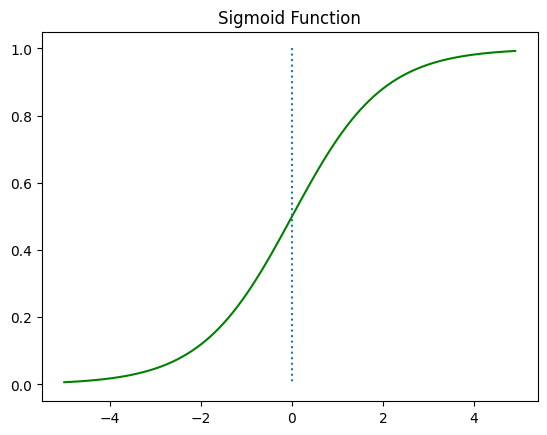

In [3]:
x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)

plt.plot(x, y, 'g')
plt.plot([0, 0], [1.0, 0.0], ':')  # 가운데 점선 추가
plt.title('Sigmoid Function')
plt.show()

시그모이드 함수는 출력값을 0과 1 사이의 값으로 조정하여 반환한다. 입력 x가 0일 때 0.5의 값을 가지며, x가 매우 커지면 1에 수렴하고 x가 매우 작아지면 0에 수렴한다.

### W값의 변화에 따른 경사도의 변화

이번에는 W의 값을 0.5, 1, 2로 바꿔 가며 그래프를 확인한다.

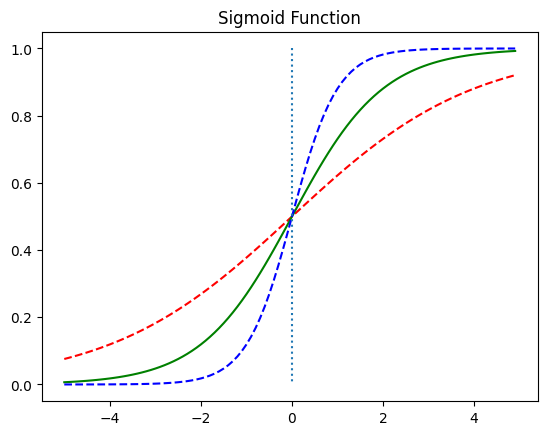

In [4]:
x = np.arange(-5.0, 5.0, 0.1)
y1 = sigmoid(0.5 * x)
y2 = sigmoid(x)
y3 = sigmoid(2 * x)

plt.plot(x, y1, 'r', linestyle='--')  # W의 값이 0.5일 때
plt.plot(x, y2, 'g')                  # W의 값이 1일 때
plt.plot(x, y3, 'b', linestyle='--')  # W의 값이 2일 때
plt.plot([0, 0], [1.0, 0.0], ':')     # 가운데 점선 추가
plt.title('Sigmoid Function')
plt.show()

W의 값이 0.5일 때 빨간색, 1일 때 초록색, 2일 때 파란색 선이다. W의 값에 따라 그래프의 **경사도**가 달라지는 것을 볼 수 있다. 선형 회귀에서 가중치 W는 직선의 기울기를 의미했지만, 여기서는 그래프의 경사도를 결정한다. W의 값이 커지면 경사가 가팔라지고, W의 값이 작아지면 경사가 완만해진다.

### b값의 변화에 따른 좌, 우 이동

이제 b의 값을 0.5, 1, 1.5로 바꿔 가며 그래프가 어떻게 변하는지 확인한다.

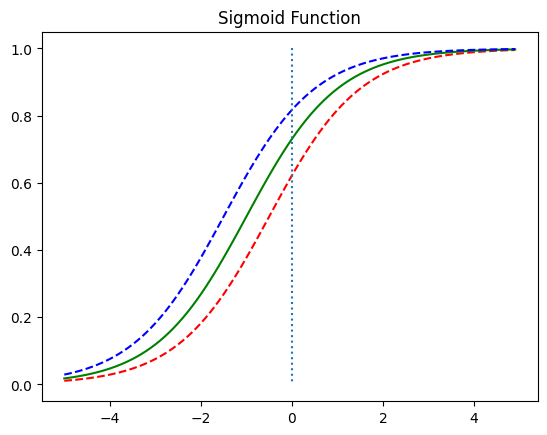

In [5]:
x = np.arange(-5.0, 5.0, 0.1)
y1 = sigmoid(x + 0.5)
y2 = sigmoid(x + 1)
y3 = sigmoid(x + 1.5)

plt.plot(x, y1, 'r', linestyle='--')  # x + 0.5
plt.plot(x, y2, 'g')                  # x + 1
plt.plot(x, y3, 'b', linestyle='--')  # x + 1.5
plt.plot([0, 0], [1.0, 0.0], ':')     # 가운데 점선 추가
plt.title('Sigmoid Function')
plt.show()

b의 값에 따라 그래프가 **좌, 우로 이동**하는 것을 볼 수 있다.

### 시그모이드 함수를 이용한 분류

시그모이드 함수는 입력값이 한없이 커지면 1에, 한없이 작아지면 0에 수렴한다. 즉 출력값이 항상 0과 1 사이의 값을 가지는데, 이 특성을 이용해 분류 작업에 사용할 수 있다.

예를 들어 임계값(threshold)을 0.5로 정하면, 출력값이 0.5 이상이면 1(True), 0.5 미만이면 0(False)으로 판단할 수 있다. 이를 확률로 생각하면, 해당 레이블에 속할 확률이 50%를 넘으면 그 레이블로 판단하고, 50%보다 낮으면 아니라고 판단하는 것으로 볼 수 있다.

## 비용 함수 (Cost Function)

로지스틱 회귀의 가설이 $H(x) = sigmoid(Wx + b)$ 임을 알았으니, 이제 최적의 W와 b를 찾을 수 있는 **비용 함수(cost function)**를 정의해야 한다. 그런데 선형 회귀에서 배운 비용 함수인 평균 제곱 오차(Mean Square Error, MSE)를 그대로 쓰면 안 될까?

$$ cost(W, b) = \frac{1}{n} \sum_{i=1}^{n} \left[ y^{(i)} - H(x^{(i)}) \right]^2 $$

위 비용 함수에서 가설은 이제 $H(x) = Wx + b$ 가 아니라 $H(x) = sigmoid(Wx + b)$ 다. 이 비용 함수를 미분하면 선형 회귀 때와 달리 심하게 울퉁불퉁한 **비볼록(non-convex)** 형태의 그래프가 나온다.

이런 그래프에 경사 하강법을 적용할 경우의 문제점은, 오차가 최솟값이 되는 구간에 도착했다고 판단한 그 지점이 실제 최솟값이 아닐 수 있다는 점이다. 등산 후 산을 내려올 때 가파른 경사를 내려오다 넓은 평지를 만나면 순간 다 내려왔다고 착각하는 것과 같다. 전체 함수에 걸친 최솟값인 **글로벌 미니멈(Global Minimum)**이 아니라 특정 구역에서의 최솟값인 **로컬 미니멈(Local Minimum)**에 갇히면, cost가 최소가 되는 가중치를 찾는다는 비용 함수의 목적에 맞지 않는다.

시그모이드 함수의 출력값은 0과 1 사이다. 따라서 실제값이 1일 때 예측값이 0에 가까워지면 오차가 커져야 하고, 실제값이 0일 때 예측값이 1에 가까워지면 오차가 커져야 한다. 이 조건을 충족하는 함수가 바로 **로그 함수**다. 실제값에 따라 다음 두 개의 로그 함수를 사용한다.

$$ \text{if } y = 1 \;\rightarrow\; \text{cost}(H(x), y) = -\log(H(x)) $$
$$ \text{if } y = 0 \;\rightarrow\; \text{cost}(H(x), y) = -\log(1 - H(x)) $$

실제값이 1일 때, 예측값 $H(x)$ 가 1이면 오차가 0이므로 cost는 0이 되고, $H(x)$ 가 0으로 수렴하면 cost는 무한대로 발산한다. 실제값이 0인 경우는 그 반대로 이해하면 된다.

이 두 식은 다음과 같이 하나의 식으로 통합할 수 있다.

$$ cost(H(x), y) = -[\, y \log H(x) + (1 - y) \log(1 - H(x)) \,] $$

왜 이 식이 두 식을 통합한 것일까? 실제값 $y$ 가 1이면 덧셈 기호를 기준으로 우측 항이 사라지고, $y$ 가 0이면 좌측 항이 사라지므로 두 경우를 모두 포괄한다. 선형 회귀에서 모든 오차의 평균을 구했듯, 여기서도 모든 샘플의 오차에 대한 평균을 구한다.

$$ cost(W) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y^{(i)} \log H(x^{(i)}) + (1 - y^{(i)}) \log(1 - H(x^{(i)})) \right] $$

정리하면, 이 비용 함수는 실제값 $y$ 와 예측값 $H(x)$ 의 차이가 커지면 cost가 커지고, 차이가 작아지면 cost도 작아진다. 이제 이 비용 함수에 대해 경사 하강법을 수행하며 최적의 가중치 W를 찾아간다.

$$ W := W - \alpha \frac{\partial}{\partial W} cost(W) $$

> 이렇게 정의한 비용 함수를 **이진 크로스 엔트로피(Binary Cross Entropy)**라 부른다.

## 파이토치로 로지스틱 회귀 구현하기

이제 파이토치로 로지스틱 회귀 중에서도 다수의 x로부터 y를 예측하는 **다중 로지스틱 회귀**를 구현한다. 먼저 필요한 도구들을 임포트한다.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.manual_seed(1)

x_data는 각 항목이 두 개의 숫자로 이루어진 입력 데이터이고, y_data는 각 입력에 해당하는 출력값(레이블)으로 0과 1로 이루어진 리스트다. 이를 `torch.FloatTensor`로 변환하여 x_train, y_train 텐서로 만든다.

In [7]:
x_data = [[1, 2], [2, 3], [3, 1], [4, 3], [5, 3], [6, 2]]
y_data = [[0], [0], [0], [1], [1], [1]]
x_train = torch.FloatTensor(x_data)
y_train = torch.FloatTensor(y_data)

행렬 연산을 사용하여 가설식을 세우기 위해 x_train과 y_train의 크기를 확인한다.

In [8]:
print(x_train.shape)
print(y_train.shape)

torch.Size([6, 2])
torch.Size([6, 1])


x_train은 (6 × 2) 크기의 행렬, y_train은 (6 × 1) 크기의 벡터다. x_train을 X, 이와 곱해지는 가중치 벡터를 W라 할 때 $XW$ 가 성립하려면 W의 크기는 (2 × 1)이어야 한다. 이제 W와 b를 `torch.zeros`로 0으로 초기화하여 선언한다.

In [9]:
W = torch.zeros((2, 1), requires_grad=True)  # 크기는 2 x 1
b = torch.zeros(1, requires_grad=True)

이제 가설식을 세운다. 파이토치에서 $e^x$ 는 `torch.exp(x)`로 구현한다. 이에 따라 행렬 연산을 사용한 가설식은 다음과 같다.

In [10]:
hypothesis = 1 / (1 + torch.exp(-(x_train.matmul(W) + b)))
print(hypothesis)  # 예측값인 H(x) 출력

tensor([[0.5000],
        [0.5000],
        [0.5000],
        [0.5000],
        [0.5000],
        [0.5000]], grad_fn=<MulBackward0>)


실제값 y_train과 크기가 같은 (6 × 1) 예측값 벡터가 나오는데, W와 b가 0으로 초기화되어 있으므로 모든 값이 0.5다.

사실 가설식은 더 간단히 구현할 수도 있다. 파이토치가 시그모이드 함수를 이미 제공하기 때문이다. 다음은 `torch.sigmoid`를 사용한 가설식으로, 앞 식과 본질적으로 동일하다.

In [11]:
hypothesis = torch.sigmoid(x_train.matmul(W) + b)
print(hypothesis)

tensor([[0.5000],
        [0.5000],
        [0.5000],
        [0.5000],
        [0.5000],
        [0.5000]], grad_fn=<SigmoidBackward0>)


앞선 결과와 동일하게 모든 값이 0.5인 (6 × 1) 예측값 벡터가 나온다. 이제 현재 예측값과 실제값 사이의 cost를 구해 본다. 우선 예측값과 실제값을 출력해 비교한다.

In [12]:
print(hypothesis)
print(y_train)

tensor([[0.5000],
        [0.5000],
        [0.5000],
        [0.5000],
        [0.5000],
        [0.5000]], grad_fn=<SigmoidBackward0>)
tensor([[0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.]])


총 6개의 원소가 있지만, 우선 하나의 샘플(하나의 원소)에 대해서만 오차를 구하는 식을 작성해 본다.

In [13]:
-(y_train[0] * torch.log(hypothesis[0]) +
  (1 - y_train[0]) * torch.log(1 - hypothesis[0]))

tensor([0.6931], grad_fn=<NegBackward0>)

이제 모든 원소에 대해 오차를 구한다.

In [14]:
losses = -(y_train * torch.log(hypothesis) +
           (1 - y_train) * torch.log(1 - hypothesis))
print(losses)

tensor([[0.6931],
        [0.6931],
        [0.6931],
        [0.6931],
        [0.6931],
        [0.6931]], grad_fn=<NegBackward0>)


그리고 이 전체 오차에 대한 평균을 구하면 그것이 cost다.

In [15]:
cost = losses.mean()
print(cost)

tensor(0.6931, grad_fn=<MeanBackward0>)


결과적으로 얻은 cost는 0.6931이다. 지금까지 비용 함수의 값을 직접 구현했는데, 사실 파이토치는 로지스틱 회귀의 비용 함수를 이미 제공한다. `torch.nn.functional as F`로 임포트한 뒤 `F.binary_cross_entropy(예측값, 실제값)` 형태로 사용하면 된다.

In [16]:
F.binary_cross_entropy(hypothesis, y_train)

tensor(0.6931, grad_fn=<BinaryCrossEntropyBackward0>)

동일하게 cost가 0.6931로 출력되는 것을 볼 수 있다. 모델의 훈련 과정까지 추가한 전체 코드는 다음과 같다.

In [17]:
x_data = [[1, 2], [2, 3], [3, 1], [4, 3], [5, 3], [6, 2]]
y_data = [[0], [0], [0], [1], [1], [1]]
x_train = torch.FloatTensor(x_data)
y_train = torch.FloatTensor(y_data)

# 모델 초기화
W = torch.zeros((2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

# optimizer 설정
optimizer = optim.SGD([W, b], lr=1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # Cost 계산
    hypothesis = torch.sigmoid(x_train.matmul(W) + b)
    cost = -(y_train * torch.log(hypothesis) +
             (1 - y_train) * torch.log(1 - hypothesis)).mean()

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 100번마다 로그 출력
    if epoch % 100 == 0:
        print('Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, nb_epochs, cost.item()
        ))

Epoch    0/1000 Cost: 0.693147
Epoch  100/1000 Cost: 0.134722
Epoch  200/1000 Cost: 0.080643
Epoch  300/1000 Cost: 0.057900
Epoch  400/1000 Cost: 0.045300
Epoch  500/1000 Cost: 0.037261
Epoch  600/1000 Cost: 0.031673
Epoch  700/1000 Cost: 0.027556
Epoch  800/1000 Cost: 0.024394
Epoch  900/1000 Cost: 0.021888
Epoch 1000/1000 Cost: 0.019852


학습이 끝났다. 훈련에 사용했던 데이터를 그대로 입력했을 때 제대로 예측하는지 확인한다. 현재 W와 b는 훈련 후의 값을 가지고 있다.

In [18]:
hypothesis = torch.sigmoid(x_train.matmul(W) + b)
print(hypothesis)

tensor([[2.7648e-04],
        [3.1608e-02],
        [3.8977e-02],
        [9.5622e-01],
        [9.9823e-01],
        [9.9969e-01]], grad_fn=<SigmoidBackward0>)


출력값이 모두 0과 1 사이의 값이다. 이제 0.5를 넘으면 True, 넘지 않으면 False로 값을 정하여 출력한다.

In [19]:
prediction = hypothesis >= torch.FloatTensor([0.5])
print(prediction)

tensor([[False],
        [False],
        [False],
        [ True],
        [ True],
        [ True]])


실제값은 `[[0], [0], [0], [1], [1], [1]]` 이므로 False, False, False, True, True, True와 동일하다. 즉 기존의 실제값과 동일하게 예측했음을 확인할 수 있다. 마지막으로 훈련된 후의 W와 b의 값을 출력한다.

In [20]:
print(W)
print(b)

tensor([[3.2530],
        [1.5179]], requires_grad=True)
tensor([-14.4819], requires_grad=True)


# 2. nn.Module과 클래스로 구현하는 로지스틱 회귀

선형 회귀 모델의 가설식은 $H(x) = Wx + b$ 였고, 이를 구현하기 위해 파이토치의 `nn.Linear()`를 사용했다. 로지스틱 회귀의 가설식은 $H(x) = sigmoid(Wx + b)$ 이고, 파이토치는 `nn.Sigmoid()`로 시그모이드 함수를 제공한다. 따라서 `nn.Linear()`의 결과를 `nn.Sigmoid()`에 통과시키면 로지스틱 회귀의 가설식이 된다. 이를 파이토치로 구현해 본다.

## nn.Linear와 nn.Sigmoid로 구현하기

먼저 필요한 도구들을 임포트하고, 훈련 데이터를 텐서로 선언한다.

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.manual_seed(1)

x_data = [[1, 2], [2, 3], [3, 1], [4, 3], [5, 3], [6, 2]]
y_data = [[0], [0], [0], [1], [1], [1]]
x_train = torch.FloatTensor(x_data)
y_train = torch.FloatTensor(y_data)

`nn.Sequential()`은 `nn.Module` 층을 차례대로 쌓을 수 있게 해 준다. 쉽게 말해 $Wx + b$ 와 같은 수식과 시그모이드 함수 등 여러 함수를 연결해 주는 역할을 한다. 뒤에서 인공 신경망을 구현할 때도 쓰이므로 기억해 두면 좋다. 이를 이용해 로지스틱 회귀를 구현한다.

In [22]:
model = nn.Sequential(
    nn.Linear(2, 1),  # input_dim = 2, output_dim = 1
    nn.Sigmoid()      # 출력은 시그모이드 함수를 거친다
)

현재 W와 b는 랜덤 초기화된 상태다. 훈련 데이터를 넣어 예측값을 확인한다.

In [23]:
model(x_train)

tensor([[0.4020],
        [0.4147],
        [0.6556],
        [0.5948],
        [0.6788],
        [0.8061]], grad_fn=<SigmoidBackward0>)

(6 × 1) 크기의 예측값 텐서가 출력된다. 다만 W와 b가 임의의 값이므로 현재 예측은 의미가 없다. 이제 경사 하강법을 사용하여 훈련한다. 총 1000번의 에포크를 수행하며, 매 10번째 에포크마다 정확도(Accuracy)를 계산하여 함께 출력한다.

In [24]:
# optimizer 설정
optimizer = optim.SGD(model.parameters(), lr=1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # H(x) 계산
    hypothesis = model(x_train)

    # cost 계산
    cost = F.binary_cross_entropy(hypothesis, y_train)

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 10번마다 로그 출력
    if epoch % 10 == 0:
        prediction = hypothesis >= torch.FloatTensor([0.5])  # 예측값이 0.5를 넘으면 True로 간주
        correct_prediction = prediction.float() == y_train   # 실제값과 일치하는 경우만 True로 간주
        accuracy = correct_prediction.sum().item() / len(correct_prediction)  # 정확도를 계산
        print('Epoch {:4d}/{} Cost: {:.6f} Accuracy {:2.2f}%'.format(
            epoch, nb_epochs, cost.item(), accuracy * 100,
        ))

Epoch    0/1000 Cost: 0.539713 Accuracy 83.33%
Epoch   10/1000 Cost: 0.614853 Accuracy 66.67%
Epoch   20/1000 Cost: 0.441875 Accuracy 66.67%
Epoch   30/1000 Cost: 0.373145 Accuracy 83.33%
Epoch   40/1000 Cost: 0.316358 Accuracy 83.33%
Epoch   50/1000 Cost: 0.266094 Accuracy 83.33%
Epoch   60/1000 Cost: 0.220498 Accuracy 100.00%
Epoch   70/1000 Cost: 0.182095 Accuracy 100.00%
Epoch   80/1000 Cost: 0.157299 Accuracy 100.00%
Epoch   90/1000 Cost: 0.144091 Accuracy 100.00%
Epoch  100/1000 Cost: 0.134272 Accuracy 100.00%
Epoch  110/1000 Cost: 0.125769 Accuracy 100.00%
Epoch  120/1000 Cost: 0.118297 Accuracy 100.00%
Epoch  130/1000 Cost: 0.111680 Accuracy 100.00%
Epoch  140/1000 Cost: 0.105779 Accuracy 100.00%
Epoch  150/1000 Cost: 0.100483 Accuracy 100.00%
Epoch  160/1000 Cost: 0.095704 Accuracy 100.00%
Epoch  170/1000 Cost: 0.091369 Accuracy 100.00%
Epoch  180/1000 Cost: 0.087420 Accuracy 100.00%
Epoch  190/1000 Cost: 0.083806 Accuracy 100.00%
Epoch  200/1000 Cost: 0.080486 Accuracy 100.00

중간부터 정확도가 100%로 나오기 시작한다. 훈련 데이터를 다시 입력하여 예측값을 확인한다.

In [25]:
model(x_train)

tensor([[2.7616e-04],
        [3.1595e-02],
        [3.8959e-02],
        [9.5624e-01],
        [9.9823e-01],
        [9.9969e-01]], grad_fn=<SigmoidBackward0>)

0.5를 넘으면 True, 낮으면 False로 간주한다. 실제값 `[[0], [0], [0], [1], [1], [1]]` 은 False, False, False, True, True, True에 해당하므로, 전부 실제값과 일치하도록 예측한 것을 확인할 수 있다. 훈련 후의 W와 b의 값을 출력한다.

In [26]:
print(list(model.parameters()))

[Parameter containing:
tensor([[3.2534, 1.5181]], requires_grad=True), Parameter containing:
tensor([-14.4839], requires_grad=True)]


출력된 W와 b의 값은 앞 챕터에서 `nn.Module`을 사용하지 않고 로지스틱 회귀를 구현했을 때 얻었던 값과 거의 일치한다.

## 인공 신경망으로 표현되는 로지스틱 회귀

사실 로지스틱 회귀는 인공 신경망(Artificial Neural Network)으로 볼 수 있다. 두 개의 입력 $x_1$, $x_2$ 가 각각 가중치 $w_1$, $w_2$ 와 곱해지고, 편향 $b$ 는 상수 1과 곱해진 뒤 모두 더해진다. 그리고 출력하기 전에 시그모이드 함수를 통과한다. 그림으로 나타내면 입력층의 두 노드($x_1$, $x_2$)와 편향 노드(1)가 하나의 출력 노드($y_1$)로 연결된 형태가 된다.

결과적으로 이 인공 신경망은 다음과 같은 다중 로지스틱 회귀를 표현한다.

$$ H(x) = sigmoid(x_1 w_1 + x_2 w_2 + b) $$

> 뒤에서 인공 신경망을 배우며 다시 언급하겠지만, 시그모이드 함수는 인공 신경망의 **은닉층**에서는 거의 사용되지 않는다.

## 모델을 클래스로 구현하기

파이토치의 대부분의 구현체는 모델을 생성할 때 **클래스(Class)**를 사용한다. 앞서 구현한 코드와 다른 점은 오직 클래스로 모델을 구현했다는 점뿐이다. 먼저 앞에서 만든 로지스틱 회귀 모델은 다음과 같았다.

```python
model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)
```

이를 클래스로 구현하면 다음과 같다.

In [27]:
class BinaryClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.linear(x))

> 클래스 형태의 모델은 `nn.Module`을 상속받는다.
> - `__init__()` : 모델의 구조와 동작을 정의하는 생성자. 객체가 생성될 때 자동 호출된다. `super()`를 부르면 이 클래스는 `nn.Module`의 속성들을 가지고 초기화된다.
> - `forward()` : 모델이 학습 데이터를 입력받아 forward 연산을 진행하는 함수. `model(입력 데이터)` 형식으로 객체를 호출하면 자동으로 실행된다.

식에 입력 x로부터 예측된 y를 얻는 것을 **forward 연산**이라 한다.

## 로지스틱 회귀 클래스로 구현하기

이제 모델을 클래스로 구현한 전체 코드를 본다. 달라진 점은 모델을 클래스로 구현했다는 점뿐이고, 나머지 코드는 모두 동일하다. `BinaryClassifier`는 두 개의 숫자를 입력받아 하나의 출력을 내는 모델로, `nn.Linear`로 입력을 선형 변환한 뒤 `Sigmoid`를 적용하여 0과 1 사이의 값을 출력한다. 이 값은 입력 데이터가 특정 클래스에 속할 확률을 나타내며, 이진 분류 문제에서 사용된다.

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch.manual_seed(1)

x_data = [[1, 2], [2, 3], [3, 1], [4, 3], [5, 3], [6, 2]]
y_data = [[0], [0], [0], [1], [1], [1]]
x_train = torch.FloatTensor(x_data)
y_train = torch.FloatTensor(y_data)

class BinaryClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.linear(x))

model = BinaryClassifier()

# optimizer 설정
optimizer = optim.SGD(model.parameters(), lr=1)

nb_epochs = 1000
for epoch in range(nb_epochs + 1):

    # H(x) 계산
    hypothesis = model(x_train)

    # cost 계산
    cost = F.binary_cross_entropy(hypothesis, y_train)

    # cost로 H(x) 개선
    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

    # 10번마다 로그 출력
    if epoch % 10 == 0:
        prediction = hypothesis >= torch.FloatTensor([0.5])
        correct_prediction = prediction.float() == y_train
        accuracy = correct_prediction.sum().item() / len(correct_prediction)
        print('Epoch {:4d}/{} Cost: {:.6f} Accuracy {:2.2f}%'.format(
            epoch, nb_epochs, cost.item(), accuracy * 100,
        ))

Epoch    0/1000 Cost: 0.539713 Accuracy 83.33%
Epoch   10/1000 Cost: 0.614853 Accuracy 66.67%
Epoch   20/1000 Cost: 0.441875 Accuracy 66.67%
Epoch   30/1000 Cost: 0.373145 Accuracy 83.33%
Epoch   40/1000 Cost: 0.316358 Accuracy 83.33%
Epoch   50/1000 Cost: 0.266094 Accuracy 83.33%
Epoch   60/1000 Cost: 0.220498 Accuracy 100.00%
Epoch   70/1000 Cost: 0.182095 Accuracy 100.00%
Epoch   80/1000 Cost: 0.157299 Accuracy 100.00%
Epoch   90/1000 Cost: 0.144091 Accuracy 100.00%
Epoch  100/1000 Cost: 0.134272 Accuracy 100.00%
Epoch  110/1000 Cost: 0.125769 Accuracy 100.00%
Epoch  120/1000 Cost: 0.118297 Accuracy 100.00%
Epoch  130/1000 Cost: 0.111680 Accuracy 100.00%
Epoch  140/1000 Cost: 0.105779 Accuracy 100.00%
Epoch  150/1000 Cost: 0.100483 Accuracy 100.00%
Epoch  160/1000 Cost: 0.095704 Accuracy 100.00%
Epoch  170/1000 Cost: 0.091369 Accuracy 100.00%
Epoch  180/1000 Cost: 0.087420 Accuracy 100.00%
Epoch  190/1000 Cost: 0.083806 Accuracy 100.00%
Epoch  200/1000 Cost: 0.080486 Accuracy 100.00

옵티마이저로 SGD(Stochastic Gradient Descent)를 설정하고 학습률을 1로 지정했다. 1000번의 에포크 동안 매 반복마다 모델을 통해 예측값 hypothesis를 계산하고, 이 예측값과 실제 레이블 y_train 간의 손실을 `binary_cross_entropy` 함수로 구해 cost 값을 얻는다. 이후 `optimizer.zero_grad()`로 기울기를 초기화하고, `cost.backward()`로 역전파를 수행하여 파라미터에 대한 기울기를 계산한 뒤, `optimizer.step()`으로 파라미터를 업데이트한다. 매 10번째 에포크마다 예측값이 0.5 이상인 경우를 True로 간주하여 이진 분류를 수행하고, 실제 레이블과 얼마나 일치하는지 비교하여 정확도를 출력한다.

> 위와 같은 클래스를 사용한 모델 구현 형식은 대부분의 파이토치 구현체에서 사용하는 방식이므로 반드시 숙지할 필요가 있다.